In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")

In [2]:
file_path = "../data/raw/yfinance_data/Data/AAPL.csv"

df = pd.read_csv(file_path)

df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [3]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3774 non-null   object 
 1   Close   3774 non-null   float64
 2   High    3774 non-null   float64
 3   Low     3774 non-null   float64
 4   Open    3774 non-null   float64
 5   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 177.0+ KB
None
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [4]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date")

df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [5]:
df["SMA_20"] = df["Close"].rolling(window=20).mean()

df[["Date", "Close", "SMA_20"]].tail()

,Date,Close,SMA_20
3769,2023-12-22,191.788757,191.856618
3770,2023-12-26,191.243912,192.018094
3771,2023-12-27,191.342972,192.154308
3772,2023-12-28,191.768951,192.362839
3773,2023-12-29,190.728775,192.490633


In [6]:
df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()

df[["Date", "Close", "EMA_20"]].tail()

,Date,Close,EMA_20
3769,2023-12-22,191.788757,191.510231
3770,2023-12-26,191.243912,191.484867
3771,2023-12-27,191.342972,191.471353
3772,2023-12-28,191.768951,191.499696
3773,2023-12-29,190.728775,191.426275


In [7]:
delta = df["Close"].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

df["RSI"] = 100 - (100 / (1 + rs))

df[["Date", "RSI"]].tail()

,Date,RSI
3769,2023-12-22,59.246127
3770,2023-12-26,49.031899
3771,2023-12-27,52.291510
3772,2023-12-28,47.920425
3773,2023-12-29,40.185234


In [8]:
ema12 = df["Close"].ewm(span=12, adjust=False).mean()
ema26 = df["Close"].ewm(span=26, adjust=False).mean()

df["MACD"] = ema12 - ema26
df["Signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

df[["Date", "MACD", "Signal"]].tail()

,Date,MACD,Signal
3769,2023-12-22,2.633141,3.235256
3770,2023-12-26,2.304751,3.049155
3771,2023-12-27,2.029104,2.845145
3772,2023-12-28,1.823998,2.640915
3773,2023-12-29,1.559539,2.424640


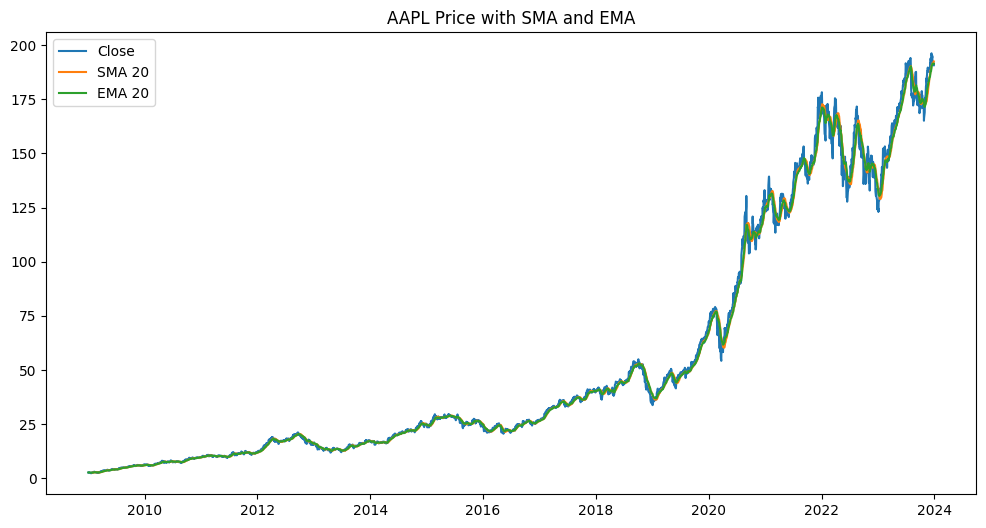

In [9]:
plt.figure(figsize=(12,6))

plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["SMA_20"], label="SMA 20")
plt.plot(df["Date"], df["EMA_20"], label="EMA 20")

plt.title("AAPL Price with SMA and EMA")
plt.legend()
plt.show()

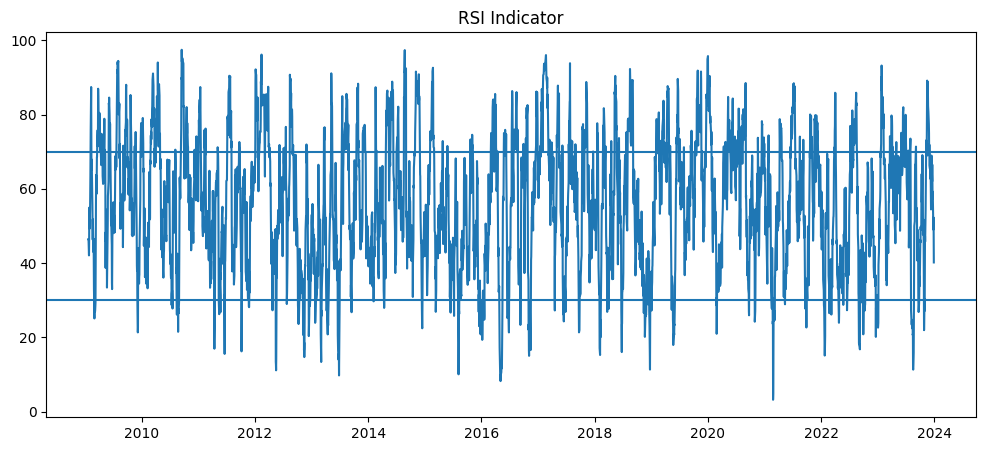

In [10]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["RSI"])

plt.axhline(70)
plt.axhline(30)

plt.title("RSI Indicator")
plt.show()

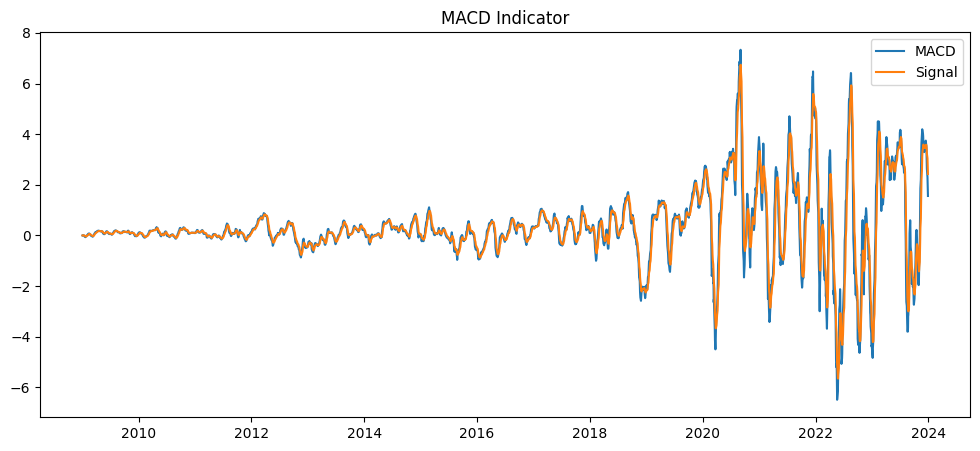

In [11]:
plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["MACD"], label="MACD")
plt.plot(df["Date"], df["Signal"], label="Signal")

plt.legend()
plt.title("MACD Indicator")

plt.show()

In [12]:
output_file = "../data/processed_AAPL.csv"

df.to_csv(output_file, index=False)

print("Saved:", output_file)

Saved: ../data/processed_AAPL.csv
